# Simon's algorithm: finding a hidden XOR mask

## The problem

A black box (the *oracle*) computes a function $f$ that maps $n$-bit strings to $n$-bit strings. We are promised there is a hidden nonzero string $s$ such that

$$f(x) = f(y) \iff y = x \;\text{ or }\; y = x \oplus s .$$

In other words, $f$ is 2-to-1, and every pair of inputs that give the same output differ by $s$ (here $\oplus$ is bitwise XOR). What is $s$?

Classically you must find two inputs with the same output (a "collision"), which takes about $2^{n/2}$ queries. Simon's algorithm needs only about $n$ queries. It was the first exponentially faster quantum algorithm of this kind, and it inspired Shor's algorithm.

## How it works

1. Hadamards put the $n$ input qubits into an equal superposition of all $x$.
2. The oracle writes $f(x)$ into $n$ output qubits.
3. Measuring the outputs would pick some value $f(x_0)$, leaving the inputs in the superposition of the pair $\{x_0,\, x_0 \oplus s\}$. (We never actually measure the outputs; the result is the same.)
4. Hadamards on the inputs, then measure them. Interference leaves only strings $y$ with $y \cdot s = 0 \pmod 2$, each equally likely.

Every shot gives one random $y$ that is "orthogonal" to $s$, which is one linear equation on the bits of $s$. Once you have $n-1$ linearly independent nonzero $y$'s (typically a bit more than $n$ shots in practice), $s$ is the only nonzero string that fits them all. That last step is ordinary classical computing, and it is cheap: see the note on scaling in Step 3.

$$|0\rangle^{n}|0\rangle^{n}
\;\xrightarrow{H^{\otimes n}\otimes I}\;
\frac{1}{\sqrt{2^n}}\sum_x |x\rangle|0\rangle
\;\xrightarrow{U_f}\;
\frac{1}{\sqrt{2^n}}\sum_x |x\rangle|f(x)\rangle
\;\xrightarrow{H^{\otimes n}\otimes I}\;
\text{measure inputs} \to y$$

## The steps

1. **Oracle**: build $U_f$ for a chosen hidden string $s$.
2. **Circuit**: wrap the oracle in Hadamards and add measurements.
3. **Run**: execute on the simulator (and optionally on hardware).
4. **Post-process**: find the $s$ that best fits the measured $y$ values.

## Setup

By default this notebook runs only on the noiseless Aer simulator. To also run on IBM hardware, set `skip_hardware=False` below (you need a saved token; see `00-Setup-Start-Here`). Hardware jobs may wait in a queue. This algorithm uses $2n$ qubits, so keep $n$ small on hardware.

In [1]:
import sys
from pathlib import Path
from types import SimpleNamespace

from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister

# Run this notebook from its own folder (the default in Jupyter and VS Code).
# The next line looks for _common.py one folder up.
sys.path.insert(0, str(Path.cwd().parent))
from _common import run_experiments

SETTINGS = SimpleNamespace(
    shots=4096,                  # shots per circuit
    backend="ibm_rensselaer",
    name="default",              # saved IBM account name
    skip_hardware=True,          # set to False to also run on IBM hardware
    poll_interval=20,
)

N = 3                # bits in the input register (the circuit uses 2N qubits)
SECRET = 0b110       # the hidden nonzero string s

## Step 1: The oracle

Qubits $0$ to $n-1$ are the inputs and qubits $n$ to $2n-1$ are the outputs. The oracle used here works in two stages:

1. Copy $x$ into the output register with $n$ CX gates: $|x\rangle|0\rangle \to |x\rangle|x\rangle$.
2. Let $j$ be the position of the lowest 1 bit of $s$. If $x_j = 1$, XOR $s$ into the output. We do this with a CX from input qubit $j$ to every output qubit where $s$ has a 1.

The result is $f(x) = x$ when $x_j = 0$ and $f(x) = x \oplus s$ when $x_j = 1$. The strings $x$ and $x \oplus s$ differ in bit $j$ (because $s_j = 1$), so exactly one of them has $x_j = 1$, and both map to the same output. That makes $f(x) = f(x \oplus s)$, and $f$ is 2-to-1.

One detail: the CX from $x_j$ onto output $j$ repeats the copy CX, so the two cancel and output bit $j$ is always 0. This is harmless, and the transpiler removes the pair, so the compiled circuit has fewer gates than the drawing suggests.

In [2]:
def build_oracle(n: int, secret: int) -> QuantumCircuit:
    '''Build a 2-to-1 oracle with hidden XOR mask ``secret``.

    Qubits 0 to n-1 are the inputs and qubits n to 2n-1 are the outputs.
    '''
    oracle = QuantumCircuit(2 * n, name=f"U_f[s={secret:0{n}b}]")
    for i in range(n):  # copy: |x>|0> -> |x>|x>
        oracle.cx(i, n + i)
    j = (secret & -secret).bit_length() - 1  # position of the lowest 1 bit of s
    # When i == j this repeats the copy CX above, so the two cancel and output
    # bit j is always 0. That is harmless (f is still 2-to-1), but the
    # transpiler removes the pair, so the compiled circuit has fewer gates.
    for i in range(n):  # if x_j = 1, XOR s into the output
        if (secret >> i) & 1:
            oracle.cx(j, n + i)
    return oracle

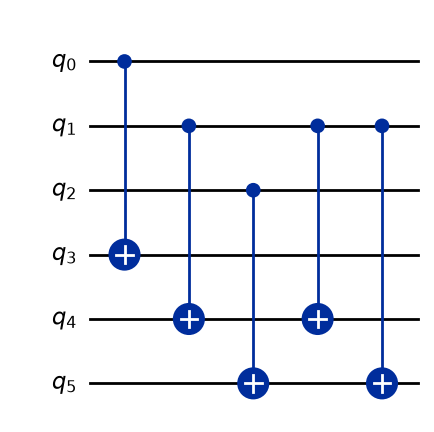

In [3]:
oracle = build_oracle(N, SECRET)
oracle.draw("mpl")

## Step 2: The full circuit

Now put the oracle between two layers of Hadamards on the input register, and measure only the $n$ input qubits. The output register is never measured. Barriers keep the three stages visually separate.

In [4]:
def build_simon_circuit(n: int, secret: int) -> QuantumCircuit:
    '''Build the full Simon circuit, measuring only the n input qubits.'''
    inputs = QuantumRegister(n, name="x")
    outputs = QuantumRegister(n, name="f")
    bits = ClassicalRegister(n, name="meas")
    circuit = QuantumCircuit(inputs, outputs, bits, name="simon")

    circuit.h(inputs)  # superposition of every input
    circuit.barrier()
    circuit.compose(  # the oracle
        build_oracle(n, secret), qubits=list(inputs) + list(outputs), inplace=True
    )
    circuit.barrier()
    circuit.h(inputs)  # interfere, then measure the inputs
    circuit.measure(inputs, bits)
    return circuit

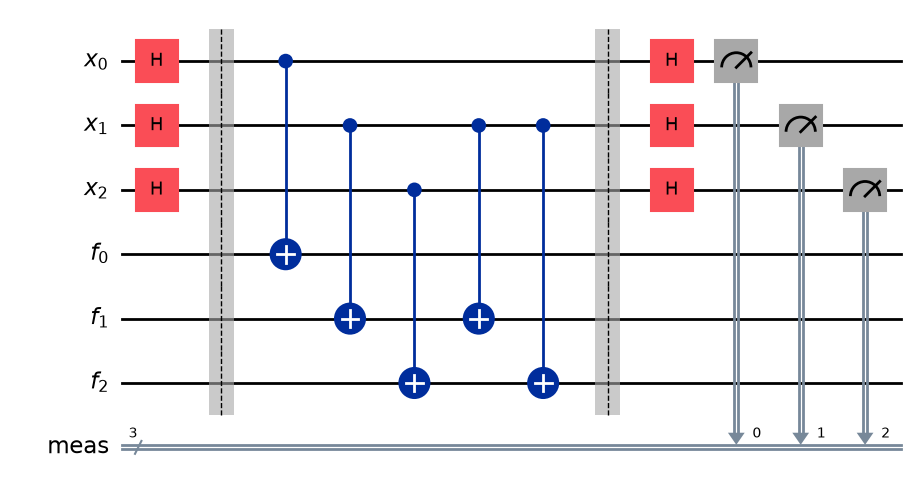

In [5]:
circuit = build_simon_circuit(N, SECRET)
circuit.draw("mpl")

## Step 3: Post-processing

Each shot gives one string $y$ with $y \cdot s = 0 \pmod 2$. The dot product counts the positions where both numbers have a 1 and keeps only whether that count is odd or even.

In [6]:
def dot(a: int, b: int) -> int:
    '''Return the bitwise inner product of a and b, mod 2.'''
    return (a & b).bit_count() & 1

Hardware noise produces some $y$ values that do not satisfy $y \cdot s = 0$, so instead of solving the linear equations exactly, we try every nonzero candidate $s$ and score it by the fraction of shots with $y \cdot s = 0$. The true $s$ scores about 1.0 and wrong candidates score about 0.5, so the best score wins even with noise.

**Caveat.** This brute-force search tries all $2^n - 1$ candidates, so this post-processing is exponential in $n$. We use it only because $n$ is tiny here and because scoring tolerates hardware noise. The scalable method is Gaussian elimination over GF(2): solve $y \cdot s = 0$ for $n-1$ linearly independent $y$'s, which costs about $O(n^3)$. That is polynomial, so the quantum speedup is not undone. We do not implement it here.

In [7]:
def recover_secret(counts: dict, n: int) -> tuple[int, float]:
    '''Find the hidden string that best fits the measured y values.

    Brute-forces all 2^n - 1 candidates (exponential in n; fine for tiny n and
    tolerant of noise). At scale, use Gaussian elimination over GF(2), about
    O(n^3).

    Returns the best candidate s and the fraction of shots with y . s = 0 for
    it. Without noise the true s scores 1.0 and every wrong candidate scores
    about 0.5.
    '''
    total = sum(counts.values())
    best = max(
        range(1, 1 << n),
        key=lambda s: sum(c for y, c in counts.items() if dot(int(y, 2), s) == 0),
    )
    score = sum(c for y, c in counts.items() if dot(int(y, 2), best) == 0) / total
    return best, score

The report function is called once per finished run. It prints the best guess for $s$, compares it with the true secret, and shows the raw counts. Remember that Qiskit prints bitstrings with qubit 0 on the *right*.

In [8]:
def report(prefix: str, name: str, counts: dict) -> None:
    s, score = recover_secret(counts, N)
    status = "correct" if s == SECRET else "WRONG"
    print(
        f"[{prefix}] best s = {s:0{N}b} ({score:.3f} of shots satisfy y.s=0) "
        f"(expected {SECRET:0{N}b}: {status})"
    )
    print(f"[{prefix}] counts: {counts}")

## Step 4: Run

`run_experiments` (from `_common.py` in the parent folder) runs each circuit on the noiseless Aer simulator and, if `skip_hardware` is `False`, on IBM hardware too. On the simulator you should see only strings $y$ with $y \cdot s = 0$, so the true $s$ scores exactly 1.0.

**What happens inside `run_experiments`.** For each backend, `_common.py` transpiles every circuit (`build_pubs`), wraps each one in a PUB, submits all the PUBs together as a single job, and matches each result back to its circuit (`counts_by_name`). One job means one wait in the hardware queue, however many circuits there are (here there is just one, so one PUB). These are the same steps as the six-step recipe in `01-Building-Blocks` (circuit, transpile, observable, PUB, execute, read). There is no observable here because we use a Sampler, which only returns bitstrings. Open `_common.py` to read the code.

To also run on hardware, set `skip_hardware=False` in the Setup cell. This needs a saved IBM token (see `00-Setup-Start-Here`), and the job may wait in a queue.

In [9]:
args = SimpleNamespace(
    shots=SETTINGS.shots,
    backend=SETTINGS.backend,
    name=SETTINGS.name,
    skip_hardware=SETTINGS.skip_hardware,
    poll_interval=SETTINGS.poll_interval,
)
print(f"Simon's algorithm, n={N} ({2 * N} qubits), hidden s = {SECRET:0{N}b}")
run_experiments({"simon": circuit}, args, report);

Simon's algorithm, n=3 (6 qubits), hidden s = 110
Example circuit (simon):
        ┌───┐ ░                           ░ ┌───┐┌─┐      
   x_0: ┤ H ├─░───■───────────────────────░─┤ H ├┤M├──────
        ├───┤ ░   │                       ░ ├───┤└╥┘┌─┐   
   x_1: ┤ H ├─░───┼────■─────────■────■───░─┤ H ├─╫─┤M├───
        ├───┤ ░   │    │         │    │   ░ ├───┤ ║ └╥┘┌─┐
   x_2: ┤ H ├─░───┼────┼────■────┼────┼───░─┤ H ├─╫──╫─┤M├
        └───┘ ░ ┌─┴─┐  │    │    │    │   ░ └───┘ ║  ║ └╥┘
   f_0: ──────░─┤ X ├──┼────┼────┼────┼───░───────╫──╫──╫─
              ░ └───┘┌─┴─┐  │  ┌─┴─┐  │   ░       ║  ║  ║ 
   f_1: ──────░──────┤ X ├──┼──┤ X ├──┼───░───────╫──╫──╫─
              ░      └───┘┌─┴─┐└───┘┌─┴─┐ ░       ║  ║  ║ 
   f_2: ──────░───────────┤ X ├─────┤ X ├─░───────╫──╫──╫─
              ░           └───┘     └───┘ ░       ║  ║  ║ 
meas: 3/══════════════════════════════════════════╩══╩══╩═
                                                  0  1  2 

--- Aer simulator (noiseless), 4096 sho

## Reading the result

For $s = 110$, the allowed outputs are the four strings $y$ with $y \cdot s = 0$: `000`, `001`, `110`, and `111`. Each should appear in about a quarter of the shots. Any other string in the counts (on hardware) is noise. Try other values of `SECRET` or `N` and rerun from the Setup cell.